# Understanding Granite 4.0 350M

This notebook is the first stop of the Any-Precision LLM reproduction. Before quantizing anything we need a precise picture of the model we are quantizing: which tensors exist, what shapes they have, which ones ADR 0002 targets for Fisher-weighted k-means, and which scaling constants sit between them.

The notebook has two parts:

1. **Architecture.** A description of `ibm-granite/granite-4.0-350m` as implemented by `GraniteMoeHybridForCausalLM` in `transformers` 5.x.
2. **Loading.** Downloading the checkpoint, confirming every claim from part 1 against the live module tree, and running a first forward pass and greedy generation.

Related decisions: [ADR 0002](../docs/adr/0002-project-layout-and-architecture.md) (quantizable-module pattern), [ADR 0003](../docs/adr/0003-fisher-weighted-kmeans-methodology.md) (methodology), [ADR 0004](../docs/adr/0004-evaluation-protocol.md) (evaluation dtype).

## 1. Architecture

Granite 4.0 350M is a **dense, attention-only decoder** that ships under the hybrid Mamba/MoE class `GraniteMoeHybridForCausalLM`. For this size, every one of the 28 layers is full attention (`transformers` 5 reports the layer type as `full_attention`; there are no Mamba layers) and `num_local_experts = 0` (no routed experts), so each layer is a classic pre-norm transformer block: grouped-query attention followed by a SwiGLU MLP (called `shared_mlp` in the code).

### 1.1 Hyperparameters

| Field | Value | Consequence |
|---|---|---|
| `num_hidden_layers` | 28 | 28 identical blocks |
| `hidden_size` $d$ | 1024 | residual stream width |
| `num_attention_heads` / `num_key_value_heads` | 16 / 4 | GQA: 4 query heads share each KV head |
| head dim $d_h$ | 64 | $1024 / 16$ |
| `shared_intermediate_size` $d_{ff}$ | 2048 | SwiGLU hidden width |
| `vocab_size` $V$ | 100352 | large vocabulary relative to $d$ |
| `tie_word_embeddings` | true | the LM head reuses the embedding matrix |
| `position_embedding_type` / `rope_theta` | rope / $10^7$ | long-context RoPE base |
| `normalization_function` | rmsnorm, $\epsilon = 10^{-5}$ | |
| `torch_dtype` | bfloat16 | released precision |

### 1.2 Forward pass

Let $E \in \mathbb{R}^{V \times d}$ be the embedding matrix and $x_{1:T}$ the input tokens. Granite was trained with μP-style scaling, which shows up as four scalar multipliers that other Llama-like models do not have:

$$h^{(0)}_t = 12 \cdot E_{x_t}$$

For each layer $\ell = 1, \dots, 28$:

$$u = h^{(\ell-1)} + 0.263 \cdot \mathrm{Attn}\big(\mathrm{RMSNorm}(h^{(\ell-1)})\big)$$

$$h^{(\ell)} = u + 0.263 \cdot \mathrm{MLP}\big(\mathrm{RMSNorm}(u)\big)$$

and the output logits are

$$z_t = \frac{1}{4}\, E\, \mathrm{RMSNorm}\big(h^{(28)}_t\big).$$

The constants are `embedding_multiplier = 12`, `residual_multiplier = 0.263` and `logits_scaling = 4`. The fourth is inside attention: scores are scaled by `attention_multiplier` $= 1/64 = 1/d_h$ rather than the usual $1/\sqrt{d_h} = 1/8$:

$$\mathrm{Attn}(y) = W_O \,\Big[\mathrm{softmax}\Big(\tfrac{1}{64}\, \mathrm{RoPE}(q_i)\, \mathrm{RoPE}(k_{g(i)})^\top + M\Big)\, v_{g(i)}\Big]_{i=1}^{16}$$

where $q = W_Q y$, $k = W_K y$, $v = W_V y$, $g(i) = \lfloor i/4 \rfloor$ maps query head $i$ to its KV head, and $M$ is the causal mask.

The MLP stores its gate and up projections **fused** in one matrix `input_linear` $= [W_G; W_U] \in \mathbb{R}^{2 d_{ff} \times d}$. The forward pass splits its output in half:

$$\mathrm{MLP}(y) = W_{\mathrm{out}}\big(\mathrm{SiLU}(W_G\, y) \odot W_U\, y\big).$$

### 1.3 Block diagram

```
 tokens [B, T]
    │  embed_tokens (E, tied)          ×12
    ▼
 h [B, T, 1024] ─────────────────────────────┐ residual
    │  input_layernorm (RMSNorm)             │
    │  q_proj [1024→1024]  k_proj [1024→256] │
    │  v_proj [1024→256]   RoPE, GQA 16/4    │
    │  o_proj [1024→1024]                    │
    └──────────────── ×0.263 ─────────── (+)─┤
    │  post_attention_layernorm (RMSNorm)    │
    │  input_linear [1024→4096] = [gate; up] │
    │  SiLU(gate) ⊙ up        [.., 2048]     │
    │  output_linear [2048→1024]             │
    └──────────────── ×0.263 ─────────── (+)─┘
    │               (repeat 28 times)
    ▼  norm (RMSNorm) → lm_head (Eᵀ, tied) → ÷4
 logits [B, T, 100352]
```

### 1.4 What gets quantized

Following ADR 0002, the quantization targets are the six `nn.Linear` modules inside every layer, which is $6 \times 28 = 168$ modules. Every row of a weight matrix $W \in \mathbb{R}^{d_{\mathrm{out}} \times d_{\mathrm{in}}}$ gets its own codebook, so the row length $d_{\mathrm{in}}$ is the number of weights sharing one lookup table.

| Module | Shape $[d_{\mathrm{out}}, d_{\mathrm{in}}]$ | Params / layer | Rows / layer |
|---|---|---|---|
| `self_attn.q_proj` | [1024, 1024] | 1,048,576 | 1024 |
| `self_attn.k_proj` | [256, 1024] | 262,144 | 256 |
| `self_attn.v_proj` | [256, 1024] | 262,144 | 256 |
| `self_attn.o_proj` | [1024, 1024] | 1,048,576 | 1024 |
| `shared_mlp.input_linear` | [4096, 1024] | 4,194,304 | 4096 |
| `shared_mlp.output_linear` | [1024, 2048] | 2,097,152 | 1024 |

The per-layer total is 8,912,896 parameters, or about 249.6M across all 28 layers. The tied embedding ($100352 \times 1024 \approx 102.8$M, about 29% of the model) and the RMSNorm gains stay in 16-bit. Two properties of this architecture are worth watching during the experiments:

- **The tied embedding is both the input and the output layer.** Quantizing it would perturb the first and the last operation at once. That is why it is excluded, and why the achievable model-level compression is bounded well below the per-linear bit-width.
- **The 0.263 residual multiplier damps each block's contribution.** A quantization error $\delta$ in a block's output enters the residual stream as $0.263\,\delta$. The Fisher weights computed in ADR 0003 capture this automatically, because the gradients flow through the same multiplier.

## 2. Loading the model

### 2.1 Setup

The constants below pin the checkpoint and restate the quantizable-module regex from `configs/model/granite_4_0_350m.yaml`, so this notebook fails loudly if the checkpoint ever diverges from ADR 0002.

In [1]:
import re
from collections import Counter

import torch
from tabulate import tabulate
from torch import nn
from transformers import (
    AutoConfig,
    AutoModelForCausalLM,
    AutoTokenizer,
    PreTrainedModel,
    PreTrainedTokenizerBase,
)

# Pin the checkpoint and seed so every rerun sees identical weights and outputs.

MODEL_ID: str = "ibm-granite/granite-4.0-350m"
REVISION: str = "main"
SEED: int = 0

# The quantizable-module pattern and count mirror the ADR 0002 model config.

QUANTIZABLE_PATTERN: re.Pattern[str] = re.compile(
    r"^model\.layers\.\d+\.(self_attn\.(q|k|v|o)_proj|shared_mlp\.(input|output)_linear)$"
)
EXPECTED_QUANTIZABLE: int = 168

torch.manual_seed(SEED)
DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_name: str = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "cpu"
print(f"torch {torch.__version__} | device {DEVICE} ({device_name})")

torch 2.9.1+cu126 | device cuda (NVIDIA GeForce RTX 3060 Laptop GPU)


### 2.2 Configuration only

The configuration is a few kilobytes, so fetching it first documents the architecture before committing to the weight download (about 0.7 GB in bfloat16).

In [2]:
config = AutoConfig.from_pretrained(MODEL_ID, revision=REVISION)

# These fields drive every shape and scaling constant described in section 1.

fields: tuple[str, ...] = (
    "model_type",
    "num_hidden_layers",
    "hidden_size",
    "shared_intermediate_size",
    "num_attention_heads",
    "num_key_value_heads",
    "vocab_size",
    "tie_word_embeddings",
    "position_embedding_type",
    "rms_norm_eps",
    "hidden_act",
    "embedding_multiplier",
    "attention_multiplier",
    "residual_multiplier",
    "logits_scaling",
    "num_local_experts",
    "max_position_embeddings",
)
# A Mamba layer would add linears outside the ADR 0002 pattern, so every layer must be attention.

layer_types: Counter[str] = Counter(config.layer_types)
config_rows: list[tuple[str, object]] = [(field, getattr(config, field, "n/a")) for field in fields]
config_rows.append(("layer_types", dict(layer_types)))
print(tabulate(config_rows, headers=["field", "value"], disable_numparse=True))
assert layer_types == Counter({"full_attention": config.num_hidden_layers})

field                     value
------------------------  ----------------------
model_type                granitemoehybrid
num_hidden_layers         28
hidden_size               1024
shared_intermediate_size  2048
num_attention_heads       16
num_key_value_heads       4
vocab_size                100352
tie_word_embeddings       True
position_embedding_type   rope
rms_norm_eps              1e-05
hidden_act                silu
embedding_multiplier      12
attention_multiplier      0.015625
residual_multiplier       0.263
logits_scaling            4
num_local_experts         0
max_position_embeddings   32768
layer_types               {'full_attention': 28}


### 2.3 Tokenizer and weights

The weights are loaded in their released bfloat16 so they can be inspected as they ship. ADR 0004 evaluates quantized models in float32, because bfloat16 has only 8 mantissa bits and can merge adjacent centroids, but that cast happens later in the pipeline.

In [3]:
def load_granite(
    model_id: str,
    revision: str,
    dtype: torch.dtype,
    device: torch.device,
) -> tuple[PreTrainedTokenizerBase, PreTrainedModel]:
    """Load the Granite tokenizer and causal-LM weights in inference mode.

    :param model_id: Hugging Face Hub repository identifier.
    :param revision: Git revision (branch, tag, or commit) of the repository.
    :param dtype: Floating-point dtype for the model parameters.
    :param device: Device on which the parameters are placed.
    :return: The tokenizer and the model with dropout disabled.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_id, revision=revision)
    model = AutoModelForCausalLM.from_pretrained(
        model_id, revision=revision, dtype=dtype, device_map=str(device)
    )
    model.eval()
    return tokenizer, model


tokenizer, model = load_granite(MODEL_ID, REVISION, torch.bfloat16, DEVICE)
first_param: torch.Tensor = next(model.parameters())
print(f"class:  {type(model).__name__}")
print(f"dtype:  {first_param.dtype} | device: {first_param.device}")
print(f"memory: {model.get_memory_footprint() / 2**20:.1f} MiB")

Loading weights:   0%|          | 0/226 [00:00<?, ?it/s]

class:  GraniteMoeHybridForCausalLM
dtype:  torch.bfloat16 | device: cuda:0
memory: 672.1 MiB


### 2.4 Module tree

Printing the whole model would repeat the same block 28 times, so only the outer shell and a single decoder layer are shown.

In [4]:
print("embed_tokens:", model.model.embed_tokens)
print("norm:        ", model.model.norm)
print("lm_head:     ", model.lm_head)
print()
print("model.layers[0] =", model.model.layers[0])

embed_tokens: Embedding(100352, 1024, padding_idx=100256)
norm:         GraniteMoeHybridRMSNorm((1024,), eps=1e-05)
lm_head:      Linear(in_features=1024, out_features=100352, bias=False)

model.layers[0] = GraniteMoeHybridDecoderLayer(
  (input_layernorm): GraniteMoeHybridRMSNorm((1024,), eps=1e-05)
  (post_attention_layernorm): GraniteMoeHybridRMSNorm((1024,), eps=1e-05)
  (shared_mlp): GraniteMoeHybridMLP(
    (activation): SiLUActivation()
    (input_linear): Linear(in_features=1024, out_features=4096, bias=False)
    (output_linear): Linear(in_features=2048, out_features=1024, bias=False)
  )
  (self_attn): GraniteMoeHybridAttention(
    (q_proj): Linear(in_features=1024, out_features=1024, bias=False)
    (k_proj): Linear(in_features=1024, out_features=256, bias=False)
    (v_proj): Linear(in_features=1024, out_features=256, bias=False)
    (o_proj): Linear(in_features=1024, out_features=1024, bias=False)
  )
)


### 2.5 Quantization targets and parameter accounting

This cell verifies the 168-module count and the per-kind shapes from section 1.4, and splits the parameter budget into quantized and 16-bit parts. Tied weights are counted once, because `model.parameters()` deduplicates shared tensors.

In [5]:
def quantizable_linears(model: nn.Module, pattern: re.Pattern[str]) -> dict[str, nn.Linear]:
    """Collect the linear layers whose qualified names match the quantization pattern.

    :param model: Model whose submodules are searched.
    :param pattern: Compiled regex matched against fully qualified module names.
    :return: Mapping from qualified module name to the matching linear layer.
    """
    return {
        name: module
        for name, module in model.named_modules()
        if isinstance(module, nn.Linear) and pattern.match(name)
    }


targets: dict[str, nn.Linear] = quantizable_linears(model, QUANTIZABLE_PATTERN)
assert len(targets) == EXPECTED_QUANTIZABLE, f"found {len(targets)} targets"

# Group targets by their in-layer suffix, e.g. "model.layers.0.self_attn.q_proj" -> "self_attn.q_proj".

shapes_by_kind: dict[str, set[tuple[int, int]]] = {}
params_by_kind: Counter[str] = Counter()
for name, linear in targets.items():
    kind: str = name.split(".", 3)[-1]
    shapes_by_kind.setdefault(kind, set()).add(tuple(linear.weight.shape))
    params_by_kind[kind] += linear.weight.numel()

print(
    tabulate(
        [
            (kind, sorted(shapes), params_by_kind[kind] / 1e6)
            for kind, shapes in shapes_by_kind.items()
        ],
        headers=["module kind", "shape", "params (M)"],
        floatfmt=".2f",
    )
)

# Split the unique parameter budget into the quantized linears, the tied embedding, and the norms.

total: int = sum(p.numel() for p in model.parameters())
embedding: int = model.get_input_embeddings().weight.numel()
quantized: int = sum(params_by_kind.values())
remainder: int = total - embedding - quantized
budget: list[tuple[str, int]] = [
    ("quantized linears", quantized),
    ("tied embedding", embedding),
    ("norms / other", remainder),
    ("total (unique)", total),
]
print()
print(
    tabulate(
        [(label, count / 1e6, 100 * count / total) for label, count in budget],
        headers=["component", "params (M)", "share (%)"],
        floatfmt=("", ".2f", ".1f"),
    )
)

# The LM head must alias the embedding storage, otherwise the embedding would be counted twice.

tied: bool = model.lm_head.weight.data_ptr() == model.model.embed_tokens.weight.data_ptr()
print(f"\nlm_head tied to embedding: {tied}")

module kind               shape             params (M)
------------------------  --------------  ------------
shared_mlp.input_linear   [(4096, 1024)]        117.44
shared_mlp.output_linear  [(1024, 2048)]         58.72
self_attn.q_proj          [(1024, 1024)]         29.36
self_attn.k_proj          [(256, 1024)]           7.34
self_attn.v_proj          [(256, 1024)]           7.34
self_attn.o_proj          [(1024, 1024)]         29.36

component            params (M)    share (%)
-----------------  ------------  -----------
quantized linears        249.56         70.8
tied embedding           102.76         29.2
norms / other              0.06          0.0
total (unique)           352.38        100.0

lm_head tied to embedding: True


### 2.6 How Gaussian are the weight rows?

Each row becomes one k-means problem in ADR 0003, so the shape of a row's value distribution determines how well $2^b$ centroids can represent it. Rotation papers such as QuaRot and SpinQuant (and our ADR 0006) are motivated by the same question: outliers make a distribution hard to quantize, and an orthogonal rotation makes it more Gaussian. Two scale-free statistics answer the question from different angles.

#### Crest factor

The crest factor is borrowed from signal processing, where it is the peak-to-RMS ratio of a waveform (audio engineers use it to judge how much headroom a signal needs before it clips). For a row $w \in \mathbb{R}^n$:

$$
\mathrm{CF}(w) = \frac{\max_j |w_j|}{\sqrt{\dfrac{1}{n}\displaystyle\sum_{j=1}^{n} w_j^2}}
$$

It answers one question: *how many RMS units away from zero is the single largest weight?* It matters because any quantization grid must reach $\max_j |w_j|$. A symmetric uniform grid with $2^b$ levels has a step of $2\max_j|w_j| / (2^b - 1)$, which is $\frac{2\,\mathrm{CF}}{2^b-1}$ in RMS units. A high crest factor therefore means that most weights share a few coarse levels.

The crest factor depends on the row length even for a fixed distribution, because the maximum of $n$ Gaussian samples grows like $\sqrt{2\ln n}$. That is why the baselines below are simulated at the two row lengths that occur in Granite, $n = 1024$ and $n = 2048$. It is also blind to everything except the single largest entry, so it cannot tell one outlier from twenty.

#### Kurtosis

Kurtosis is the standardized fourth moment of the row:

$$
\kappa(w) = \frac{\dfrac{1}{n}\displaystyle\sum_{j=1}^{n} (w_j - \bar w)^4}{\left(\dfrac{1}{n}\displaystyle\sum_{j=1}^{n} (w_j - \bar w)^2\right)^2}, \qquad \bar w = \frac{1}{n}\sum_{j=1}^{n} w_j
$$

This is the *Pearson* kurtosis, which SpinQuant reports: a Gaussian has $\kappa = 3$, a Laplacian $\kappa = 6$, and a uniform distribution $\kappa = 1.8$. *Excess* kurtosis is $\kappa - 3$, so that a Gaussian scores 0. Kurtosis is often described as measuring "peakedness", but it really measures **tail weight**: the fourth power makes it dominated by the entries far from the mean. A single outlier at $c$ standard deviations in an otherwise Gaussian row adds roughly

$$
\Delta\kappa \approx \frac{c^4}{n},
$$

so one weight at $c = 30$ in a row of $n = 2048$ pushes $\kappa$ from 3 to about 400. Kurtosis and the crest factor therefore complement each other. The crest factor measures how extreme the worst entry is, and kurtosis measures how much of the row's spread lives in its tails. SpinQuant usually reports kurtosis per tensor or per activation channel. Here it is computed **per row**, because each row gets its own codebook.

Both statistics are computed below for 20,000 simulated rows per reference distribution, then for every row of the 168 quantizable modules. The crest factor uses the uncentred RMS, because the grid is anchored at zero. Granite's rows have means very close to zero, so centring would not change it noticeably.

In [6]:
from collections.abc import Callable
from dataclasses import dataclass

import matplotlib.pyplot as plt


def row_shape_statistics(weight: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """Compute the crest factor and the Pearson kurtosis of every row of a matrix.

    :param weight: Matrix of shape ``[rows, n]``; each row is one sample of ``n`` values.
    :return: Crest factors and kurtoses, each of shape ``[rows]``.
    """
    # Promote to float32 so fourth powers neither overflow nor lose precision in bfloat16.

    values: torch.Tensor = weight.float()

    # The crest factor uses the uncentred RMS because a quantization grid is anchored at zero.
    # [rows, n] -> [rows]

    crest: torch.Tensor = values.abs().amax(dim=1) / values.pow(2).mean(dim=1).sqrt()

    # Kurtosis centres each row first: [rows, n] - [rows, 1] -> [rows, n], then reduces to [rows].

    deviations: torch.Tensor = values - values.mean(dim=1, keepdim=True)
    variance: torch.Tensor = deviations.pow(2).mean(dim=1)
    kurtosis: torch.Tensor = deviations.pow(4).mean(dim=1) / variance.pow(2)
    return crest, kurtosis


@dataclass(frozen=True)
class ShapeSummary:
    """Median, 99th percentile, and maximum of the per-row crest factor and kurtosis.

    :param label: Name of the distribution or module kind.
    :param n: Row length.
    :param crest: ``(median, p99, max)`` of the crest factor.
    :param kurtosis: ``(median, p99, max)`` of the Pearson kurtosis.
    """

    label: str
    n: int
    crest: tuple[float, float, float]
    kurtosis: tuple[float, float, float]


def _median_p99_max(values: torch.Tensor) -> tuple[float, float, float]:
    """Reduce a 1-D tensor to its median, 99th percentile, and maximum.

    :param values: Tensor of shape ``[rows]``.
    :return: The three order statistics as Python floats.
    """
    quantiles: torch.Tensor = torch.quantile(values.float().cpu(), torch.tensor([0.5, 0.99]))
    return quantiles[0].item(), quantiles[1].item(), values.max().item()


def summarize(label: str, n: int, crest: torch.Tensor, kurtosis: torch.Tensor) -> ShapeSummary:
    """Summarize per-row statistics for one distribution or module kind.

    :param label: Name shown in the table.
    :param n: Row length.
    :param crest: Per-row crest factors, shape ``[rows]``.
    :param kurtosis: Per-row kurtoses, shape ``[rows]``.
    :return: The summary record.
    """
    return ShapeSummary(label, n, _median_p99_max(crest), _median_p99_max(kurtosis))


def print_summaries(summaries: list[ShapeSummary]) -> None:
    """Print summaries as an aligned text table.

    :param summaries: Records to print, one per line.
    """
    headers: list[str] = [
        "source",
        "n",
        "crest median",
        "crest p99",
        "crest max",
        "kurtosis median",
        "kurtosis p99",
        "kurtosis max",
    ]
    table = [(s.label, s.n, *s.crest, *s.kurtosis) for s in summaries]
    print(tabulate(table, headers=headers, floatfmt=".2f"))

In [7]:
REFERENCE_ROWS: int = 20_000
ROW_LENGTHS: tuple[int, ...] = (1024, 2048)
generator: torch.Generator = torch.Generator(device=DEVICE).manual_seed(SEED)


def sample_gaussian(shape: tuple[int, int]) -> torch.Tensor:
    """Draw standard normal samples.

    :param shape: Output shape ``(rows, n)``.
    :return: Samples on ``DEVICE`` drawn from the seeded ``generator``.
    """
    return torch.randn(shape, generator=generator, device=DEVICE)


def sample_laplace(shape: tuple[int, int]) -> torch.Tensor:
    """Draw unit-scale Laplace samples, drawn as the difference of two exponentials.

    :param shape: Output shape ``(rows, n)``.
    :return: Samples on ``DEVICE`` drawn from the seeded ``generator``.
    """
    first = torch.empty(shape, device=DEVICE).exponential_(generator=generator)
    return first - torch.empty(shape, device=DEVICE).exponential_(generator=generator)


def sample_uniform(shape: tuple[int, int]) -> torch.Tensor:
    """Draw samples uniform on ``[-1, 1)``.

    :param shape: Output shape ``(rows, n)``.
    :return: Samples on ``DEVICE`` drawn from the seeded ``generator``.
    """
    return 2.0 * torch.rand(shape, generator=generator, device=DEVICE) - 1.0


SAMPLERS: dict[str, Callable[[tuple[int, int]], torch.Tensor]] = {
    "Gaussian (kappa = 3)": sample_gaussian,
    "Laplace (kappa = 6)": sample_laplace,
    "Uniform (kappa = 1.8)": sample_uniform,
}

# Each reference row has the same length as a Granite row, so extreme-value effects match.
# [REFERENCE_ROWS, n] -> two [REFERENCE_ROWS] statistics per (distribution, n) pair.

reference_summaries: list[ShapeSummary] = []
gaussian_median_crest: dict[int, float] = {}
for label, sampler in SAMPLERS.items():
    for n in ROW_LENGTHS:
        ref_crest, ref_kurtosis = row_shape_statistics(sampler((REFERENCE_ROWS, n)))
        reference_summaries.append(summarize(label, n, ref_crest, ref_kurtosis))
        if label.startswith("Gaussian"):
            gaussian_median_crest[n] = reference_summaries[-1].crest[0]

In [8]:
# Collect per-row statistics for every quantizable module, tagging each row with its origin.

kinds: list[str] = list(dict.fromkeys(name.split(".", 3)[-1] for name in targets))
crest_parts: dict[str, list[torch.Tensor]] = {kind: [] for kind in kinds}
kurtosis_parts: dict[str, list[torch.Tensor]] = {kind: [] for kind in kinds}
row_origin: list[tuple[str, int, int]] = []
all_crest: list[torch.Tensor] = []
all_kurtosis: list[torch.Tensor] = []
with torch.no_grad():
    for name, linear in targets.items():
        layer: int = int(name.split(".")[2])
        kind: str = name.split(".", 3)[-1]

        # [d_out, d_in] -> two [d_out] vectors, one value per future codebook.

        crest, kurtosis = row_shape_statistics(linear.weight)
        crest_parts[kind].append(crest.cpu())
        kurtosis_parts[kind].append(kurtosis.cpu())
        all_crest.append(crest.cpu())
        all_kurtosis.append(kurtosis.cpu())
        row_origin.extend((kind, layer, row) for row in range(crest.numel()))

# Concatenate the 28 layers of each kind: 28 x [d_out] -> [28 * d_out], then print next to the references.

granite_summaries: list[ShapeSummary] = [
    summarize(
        f"Granite {kind}",
        targets[f"model.layers.0.{kind}"].in_features,
        torch.cat(crest_parts[kind]),
        torch.cat(kurtosis_parts[kind]),
    )
    for kind in kinds
]
print_summaries(reference_summaries + granite_summaries)

source                               n    crest median    crest p99    crest max    kurtosis median    kurtosis p99    kurtosis max
--------------------------------  ----  --------------  -----------  -----------  -----------------  --------------  --------------
Gaussian (kappa = 3)              1024            3.40         4.42         5.44               2.98            3.40            3.85
Gaussian (kappa = 3)              2048            3.58         4.54         5.86               2.99            3.27            3.51
Laplace (kappa = 6)               1024            5.16         7.93        12.70               5.73            9.20           29.87
Laplace (kappa = 6)               2048            5.65         8.50        12.63               5.83            8.26           17.37
Uniform (kappa = 1.8)             1024            1.73         1.79         1.83               1.80            1.89            1.94
Uniform (kappa = 1.8)             2048            1.73         1.77         

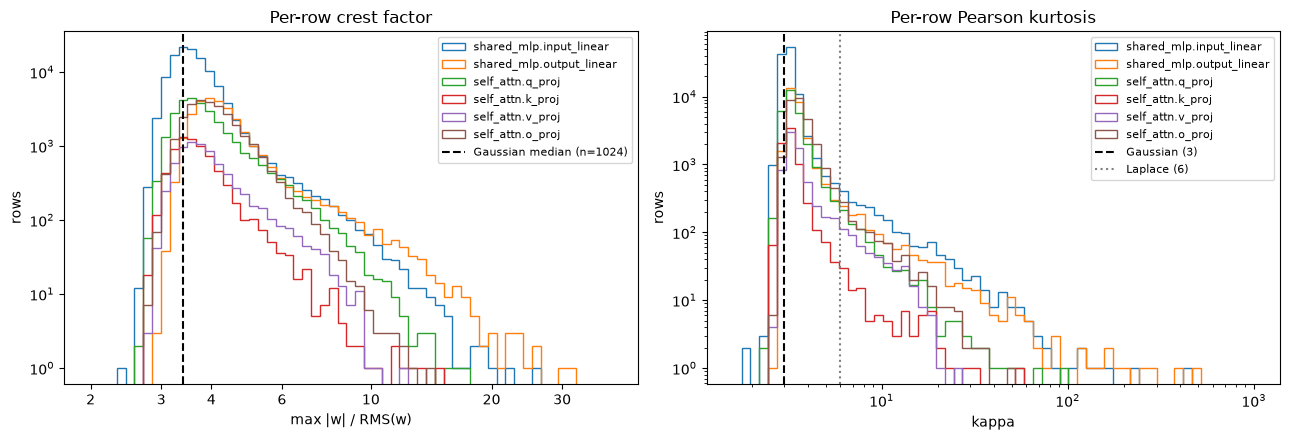

In [9]:
# Log-spaced bins, because both statistics span two to three orders of magnitude across rows.

crest_bins: torch.Tensor = torch.logspace(0.3, 1.6, 60)
kurtosis_bins: torch.Tensor = torch.logspace(0.2, 3.0, 60)
fig, (ax_crest, ax_kurtosis) = plt.subplots(1, 2, figsize=(13, 4.5))
for kind in kinds:
    ax_crest.hist(
        torch.cat(crest_parts[kind]).numpy(), bins=crest_bins.numpy(), histtype="step", label=kind
    )
    ax_kurtosis.hist(
        torch.cat(kurtosis_parts[kind]).numpy(),
        bins=kurtosis_bins.numpy(),
        histtype="step",
        label=kind,
    )

# Reference lines: the Gaussian median crest factor at n = 1024 and the Gaussian and Laplace kurtoses.

ax_crest.axvline(
    gaussian_median_crest[1024], color="black", linestyle="--", label="Gaussian median (n=1024)"
)
ax_kurtosis.axvline(3.0, color="black", linestyle="--", label="Gaussian (3)")
ax_kurtosis.axvline(6.0, color="gray", linestyle=":", label="Laplace (6)")
for ax, title in ((ax_crest, "Histogram: Per-row crest factor"), (ax_kurtosis, "Histogram: Per-row Pearson kurtosis")):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_ylabel("rows")
    ax.legend(fontsize=8)
# Plain tick labels: matplotlib's default log-axis minor labels overlap on this range.

ax_crest.set_xticks([2, 3, 4, 6, 10, 20, 30], labels=["2", "3", "4", "6", "10", "20", "30"])
ax_crest.minorticks_off()
ax_crest.set_xlabel("max |w| / RMS(w)")
ax_kurtosis.set_xlabel("kappa")
fig.tight_layout()
plt.show()

In [10]:
# Rank every row in the model by crest factor to see where the extreme rows live.
# 168 x [d_out] -> [total_rows], then keep the top entries.

flat_crest: torch.Tensor = torch.cat(all_crest)
flat_kurtosis: torch.Tensor = torch.cat(all_kurtosis)
TOP_ROWS: int = 12
top_rows: list[tuple[str, int, int, float, float]] = []
for index in flat_crest.topk(TOP_ROWS).indices.tolist():
    kind, layer, row = row_origin[index]
    top_rows.append((kind, layer, row, flat_crest[index].item(), flat_kurtosis[index].item()))
print(
    tabulate(
        top_rows,
        headers=["module kind", "layer", "row", "crest", "kurtosis"],
        floatfmt=("", "", "", ".2f", ".1f"),
    )
)

# Count rows whose kurtosis exceeds the Laplace value, per kind, to size the heavy-tailed population.

heavy_rows: list[tuple[str, int, int, float]] = []
for kind in kinds:
    kurt: torch.Tensor = torch.cat(kurtosis_parts[kind])
    heavy: int = int((kurt > 6.0).sum())
    heavy_rows.append((kind, heavy, kurt.numel(), 100 * heavy / kurt.numel()))
print()
print(
    tabulate(
        heavy_rows,
        headers=["module kind", "rows with kurtosis > 6", "rows", "share (%)"],
        floatfmt=".2f",
    )
)

module kind                 layer    row    crest    kurtosis
------------------------  -------  -----  -------  ----------
shared_mlp.output_linear        2    582    31.57       486.6
shared_mlp.output_linear        2     43    30.30       411.9
shared_mlp.output_linear       13    505    25.88       290.8
shared_mlp.input_linear        27   1922    25.78       431.9
shared_mlp.output_linear        2     58    25.37       264.4
shared_mlp.output_linear       26     58    25.15       198.2
shared_mlp.output_linear        2    860    23.89       162.5
shared_mlp.output_linear        3     58    23.83       159.0
shared_mlp.output_linear       17    910    23.25       149.2
shared_mlp.output_linear        2    517    22.71       191.6
shared_mlp.output_linear       14    350    22.45       128.1
shared_mlp.output_linear        3    517    22.31       122.3

module kind                 rows with kurtosis > 6    rows    share (%)
------------------------  ------------------------  ------ 

#### Takeaways for Granite

**The typical row is close to Gaussian.** Median kurtosis ranges from 3.12 (`input_linear`) to 3.54 (`o_proj`), against 2.98 for simulated Gaussian rows and 5.7 to 5.8 for Laplacian rows. The median crest factors (3.55 to 4.13) sit just above the Gaussian values for their row lengths (3.40 at $n=1024$, 3.58 at $n=2048$). For most rows, a $2^b$-centroid codebook only has to model a slightly heavy-tailed bell curve.

**A small population of rows is far heavier-tailed than any Laplacian.** Between 1.5% (`k_proj`) and 6.5% (`v_proj`) of rows have $\kappa > 6$, and the extremes reach $\kappa \approx 490$ with crest factors above 30. No simulated Gaussian row out of 20,000 exceeded a crest factor of 5.9 or a kurtosis of 3.9.

**Those extremes are single outliers, not broad tails.** The worst row (layer 2, `output_linear`, row 582) has $\mathrm{CF} = 31.6$ and $n = 2048$. The single-outlier estimate gives $3 + 31.6^4/2048 \approx 488$, and the measured kurtosis is 486.6. That row is essentially a Gaussian row plus one enormous weight. This is exactly the situation in which the crest factor and kurtosis are both extreme.

**The outliers are structured.** Ten of the twelve most extreme rows are in `shared_mlp.output_linear`, five of them in layer 2. The same row indices recur across layers: row 58 appears in layers 2, 3, and 26, and row 517 in layers 2 and 3. A row of `output_linear` is the set of weights that write to one channel of the 1024-wide residual stream. The recurring indices therefore point at a few residual channels into which several MLPs write unusually large values, which resembles the "massive activation" channels reported for other LLMs. This is a hypothesis to confirm with activations, not a measured fact yet.

**Consequences for the method:**

- *Uniform grids.* At 3 bits and $\mathrm{CF} = 31.6$, the symmetric uniform step is $2 \cdot 31.6 / 7 \approx 9$ RMS units, so nearly the whole row collapses onto the two levels nearest zero. Round-to-nearest cannot handle these rows without clipping or outlier extraction.
- *Weighted k-means (ADR 0003).* By the contiguity lemma, a single outlier can take a centroid of its own, which costs one of the 8 seed centroids instead of the whole row's resolution. Whether k-means spends that centroid depends on the outlier's Fisher weight, which [02_Fisher_and_KMeans.ipynb](02_Fisher_and_KMeans.ipynb) measures.
- *Hadamard rotation (ADR 0006).* Rotating a row spreads one spike of height $c$ across all $n$ coordinates at height about $c/\sqrt{n}$, which would bring these rows back to the Gaussian regime. For the 95% or more of rows that are already near-Gaussian, rotation has little to gain. That is consistent with the modest 0.36-bit Panter–Dite estimate in ADR 0006.

### 2.7 Forward pass and loss

Passing `labels=input_ids` makes the model compute the shifted next-token cross-entropy internally. This is the same loss whose per-sequence gradients produce the empirical Fisher in ADR 0003. `logits_scaling` is already applied inside the model's forward pass, so the returned logits are the ones the softmax sees.

In [11]:
text: str = (
    "Post-training quantization compresses a trained network by mapping each weight "
    "to one of a small number of representative values."
)
encoded = tokenizer(text, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    output = model(**encoded, labels=encoded["input_ids"])

# logits: [batch=1, T, V]; the loss averages over the T - 1 shifted prediction positions.

print(f"input_ids: {tuple(encoded['input_ids'].shape)}")
print(f"logits:    {tuple(output.logits.shape)} ({output.logits.dtype})")
print(f"loss:      {output.loss.item():.3f} nats/token | perplexity {output.loss.exp().item():.2f}")

input_ids: (1, 23)
logits:    (1, 23, 100352) (torch.bfloat16)
loss:      4.305 nats/token | perplexity 74.08


### 2.8 Greedy generation with the chat template

Granite 4.0 350M is instruction-tuned, so prompts go through its chat template. Greedy decoding (`do_sample=False`) keeps the output deterministic, which is the setting ADR 0004 and ADR 0007 use when comparing precisions.

In [12]:
messages: list[dict[str, str]] = [
    {
        "role": "user",
        "content": "In two sentences, what is post-training quantization of a neural network?",
    }
]

# Show the rendered template once so the special-token framing is visible.

print(tokenizer.apply_chat_template(messages, add_generation_prompt=True, tokenize=False))

chat_inputs = tokenizer.apply_chat_template(
    messages, add_generation_prompt=True, return_dict=True, return_tensors="pt"
).to(DEVICE)
with torch.no_grad():
    generated: torch.Tensor = model.generate(**chat_inputs, max_new_tokens=96, do_sample=False)

# [1, prompt_len + new_len] -> [new_len]: drop the echoed prompt tokens before decoding.

prompt_len: int = chat_inputs["input_ids"].shape[1]
print(tokenizer.decode(generated[0, prompt_len:], skip_special_tokens=True))

<|start_of_role|>system<|end_of_role|>You are a helpful assistant. Please ensure responses are professional, accurate, and safe.<|end_of_text|>
<|start_of_role|>user<|end_of_role|>In two sentences, what is post-training quantization of a neural network?<|end_of_text|>
<|start_of_role|>assistant<|end_of_role|>


Post-training quantization of a neural network involves reducing the precision of the weights and activations during the training process to decrease memory usage and improve inference speed.


## 3. Next steps

The empirical Fisher diagonal, the 3-bit weighted k-means seed, and incremental upscaling to 8 bits continue in [02_Fisher_and_KMeans.ipynb](02_Fisher_and_KMeans.ipynb).